# Data science basics

## Numpy

In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create a NumPy array
array = np.array([1, 2, 3, 4, 5])
array


array([1, 2, 3, 4, 5])

In [4]:
# Basic operations
print(array + 5)  # Element-wise addition
print(array * 2)  # Element-wise multiplication


[ 6  7  8  9 10]
[ 2  4  6  8 10]


In [5]:
# Multi-dimensional arrays
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(matrix)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [6]:
slice1 = matrix[1:,1:]
slice1

array([[5, 6],
       [8, 9]])

In [7]:
numbers = matrix.reshape((9, ))

In [8]:
numbers[ numbers>2 ]

array([3, 4, 5, 6, 7, 8, 9])

## Pandas

In [9]:
import pandas as pd

# Create a DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40],
    'Department': ['HR', 'IT', 'Finance', 'Marketing']
}
data


{'Name': ['Alice', 'Bob', 'Charlie', 'David'],
 'Age': [25, 30, 35, 40],
 'Department': ['HR', 'IT', 'Finance', 'Marketing']}

In [10]:
df = pd.DataFrame(data)
df


,Name,Age,Department
0,Alice,25,HR
1,Bob,30,IT
2,Charlie,35,Finance
3,David,40,Marketing


### Basic operations

In [11]:
df.describe()

,Age
count,4.000000
mean,32.500000
std,6.454972
min,25.000000
25%,28.750000
50%,32.500000
75%,36.250000
max,40.000000


In [12]:
df[df['Age']>30]

,Name,Age,Department
2,Charlie,35,Finance
3,David,40,Marketing


## Load data

In [13]:
df = pd.read_csv('./developers.csv')
df

,Developer,Age,Salary
0,Alice,30,60000
1,Boris,25,55000
2,Charlie,35,70000
3,Dimitar,28,62000
4,Eve,32,65000
5,Georgi,27,58000
6,Grace,40,80000
7,Hristo,29,61000
8,Ivan,31,63000
9,Kaloyan,26,57000


In [ ]:
tables = pd.read_html('https://pandas.pydata.org/docs/user_guide/io.html')
tables[0]

In [17]:
df.shape

(10, 3)

In [19]:
df.tail(3)

,Developer,Age,Salary
7,Hristo,29,61000
8,Ivan,31,63000
9,Kaloyan,26,57000


In [24]:
df.iloc[1]

Developer    Boris
Age             25
Salary       55000
Name: 1, dtype: object

In [26]:
df.sort_values(by='Age')

,Developer,Age,Salary
1,Boris,25,55000
9,Kaloyan,26,57000
5,Georgi,27,58000
3,Dimitar,28,62000
7,Hristo,29,61000
0,Alice,30,60000
8,Ivan,31,63000
4,Eve,32,65000
2,Charlie,35,70000
6,Grace,40,80000


In [28]:
df['Age'] >= 30

0     True
1    False
2     True
3    False
4     True
5    False
6     True
7    False
8     True
9    False
Name: Age, dtype: bool

In [29]:
df[[True, False,True, False,True, False,True, False,True, False]]

,Developer,Age,Salary
0,Alice,30,60000
2,Charlie,35,70000
4,Eve,32,65000
6,Grace,40,80000
8,Ivan,31,63000


In [33]:
df[df['Age'] >= 30]

,Developer,Age,Salary
0,Alice,30,60000
2,Charlie,35,70000
4,Eve,32,65000
6,Grace,40,80000
8,Ivan,31,63000


In [34]:
# Filter data based on multiple conditions
mean_salary = df['Salary'].mean()
mean_salary

np.float64(63100.0)

In [37]:
new_df = df[(df['Age'] <= 35) & (df['Salary'] >= mean_salary)]

In [38]:
new_df

,Developer,Age,Salary
2,Charlie,35,70000
4,Eve,32,65000


In [ ]:
# 1. Basic CSV export
new_df.to_csv('developers_basic.csv', index=False)


In [42]:
# 2. Excel with sheet name specified
new_df.to_excel('developers_named_sheet.xlsx',
            sheet_name='Developer_Data',
            index=False)

## Matplotlib

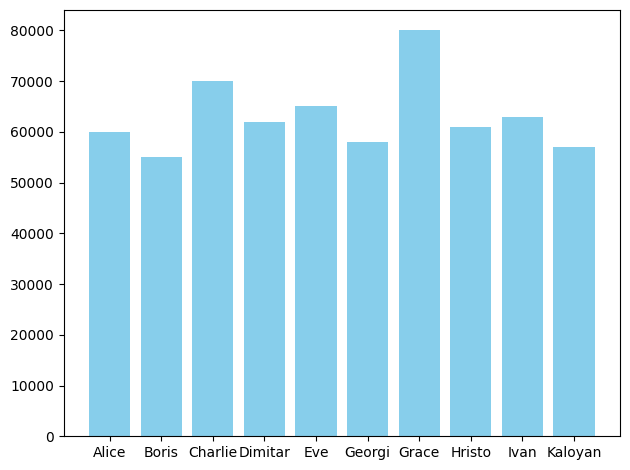

In [45]:
plt.bar(df['Developer'], df['Salary'], color='skyblue')
plt.tight_layout()

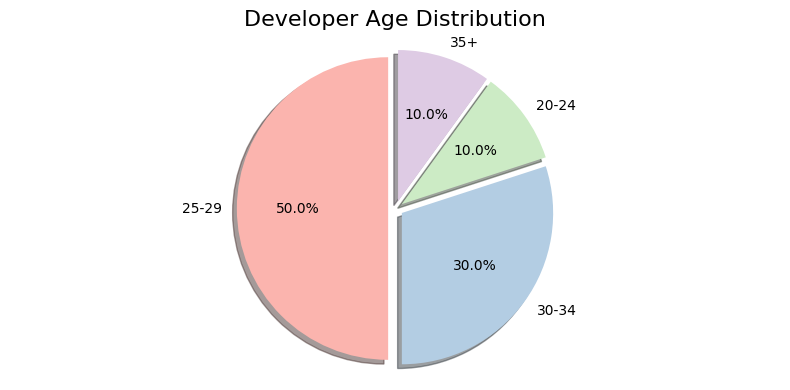

In [46]:
plt.figure(figsize=(8, 4))
age_bins = [20, 25, 30, 35, 45]
age_labels = ['20-24', '25-29', '30-34', '35+']

df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
age_counts = df['Age Group'].value_counts()

plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%',
        startangle=90, shadow=True, explode=[0.05]*len(age_counts),
        colors=plt.cm.Pastel1.colors)

plt.title('Developer Age Distribution', fontsize=16)

plt.axis('equal')
plt.tight_layout()